# Strong Inductive Bias SSL-JEPA: Sum-Preserving Augmentations

## The Argument

We established that truly self-supervised JEPA (token masking, dropout, swap) cannot
grok modular addition because the input pair $(a, b)$ does not specify which operation
is being learned. The label $c = (a+b) \bmod p$ is necessary — but *in what form?*

The Label-JEPA feeds $c$ explicitly to the target encoder. But there's a subtler way
to inject the same information: **encode the operation inside the augmentation.**

A **sum-preserving augmentation** maps $(a, b) \to (a+k, b-k) \bmod p$ for random $k$.
Both pairs have the same sum. No label $c$ ever appears. Both encoders see only input
pairs. This is formally SSL — delete every label from the dataset and training proceeds
identically.

But the augmentation *is* the task specification. Designing it required knowing that
addition is the relevant operation. The human encoded the answer into the procedure.

## What This Notebook Tests

| Approach | Context sees | Target sees | Label used? | Operation encoded in? |
|----------|-------------|-------------|-------------|----------------------|
| **E1. Sum-preserving** | $(a, b)$ | $(a{+}k, b{-}k) \bmod p$ | No | Augmentation |
| **E2. Product-preserving** | $(a, b)$ | $(a \cdot r, b \cdot r^{-1}) \bmod p$ | No | Augmentation (wrong task) |
| **E3. Random remapping** | $(a, b)$ | $(\pi(a), \sigma(b))$ for fixed permutations | No | Nothing (control) |
| **D. Label-JEPA** | $(a, b)$ | $c = (a{+}b) \bmod p$ | Yes | Target encoder input |

**E2 (product-preserving)** is the critical control. It uses the *same technique*
(operation-preserving augmentation) but encodes the *wrong operation* (multiplication
instead of addition). If E1 groks addition and E2 does not, it proves the augmentation
is doing the task specification work — the model learns whatever operation the
augmentation encodes.

**E3 (random remapping)** applies fixed random permutations to each operand independently.
This creates a consistent augmentation (same input always maps to the same augmented view)
but one that does not preserve any algebraic structure. It controls for the possibility
that any consistent pairing is sufficient.

## Key Questions

1. Can sum-preserving augmentation JEPA grok modular addition?
2. If yes — does it follow the Fourier pathway or the non-Fourier pathway?
3. Does product-preserving augmentation cause grokking of addition or multiplication?
4. Is the augmentation genuinely functioning as task specification?

## 1. Setup & Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import time
from copy import deepcopy
from torch.utils.data import TensorDataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Hyperparameters

In [2]:
p = 97
train_frac = 0.3

LATENT_DIM = 128
HIDDEN_DIM = 256
PREDICTOR_DIM = 64

EPOCHS = 100_000
LR = 1e-3
WEIGHT_DECAY = 1.0
EMA_DECAY = 0.996

LOG_EVERY = 200
PROBE_EVERY = 500

print(f"Task: (a + b) mod {p}")
print(f"Total pairs: {p**2}, Train: {int(train_frac * p**2)}, Val: {p**2 - int(train_frac * p**2)}")

Task: (a + b) mod 97
Total pairs: 9409, Train: 2822, Val: 6587


## 3. Dataset

In [3]:
pairs = torch.cartesian_prod(torch.arange(p), torch.arange(p))
targets = (pairs[:, 0] + pairs[:, 1]) % p

n = len(pairs)
n_train = int(train_frac * n)
n_val = n - n_train

perm = torch.randperm(n, generator=torch.Generator().manual_seed(SEED))
train_idx, val_idx = perm[:n_train], perm[n_train:]

train_pairs = pairs[train_idx].to(device)
train_targets = targets[train_idx].to(device)
val_pairs = pairs[val_idx].to(device)
val_targets = targets[val_idx].to(device)

train_loader = DataLoader(
    TensorDataset(train_pairs, train_targets),
    batch_size=n_train, shuffle=True
)

print(f"Train: {n_train} | Val: {n_val}")

# Precompute modular inverse table for product-preserving augmentation
# For prime p, a^(-1) = a^(p-2) mod p (Fermat's little theorem)
mod_inverse = torch.zeros(p, dtype=torch.long)
for i in range(1, p):
    mod_inverse[i] = pow(i, p - 2, p)
mod_inverse = mod_inverse.to(device)

# Precompute fixed random permutations for E3
rng = torch.Generator().manual_seed(SEED + 999)
perm_a = torch.randperm(p, generator=rng)  # fixed permutation for operand a
perm_b = torch.randperm(p, generator=rng)  # fixed permutation for operand b
perm_a = perm_a.to(device)
perm_b = perm_b.to(device)

print(f"Modular inverse table computed (e.g., 3^(-1) mod {p} = {mod_inverse[3].item()})")
print(f"Check: 3 × {mod_inverse[3].item()} mod {p} = {(3 * mod_inverse[3].item()) % p}")

Train: 2822 | Val: 6587
Modular inverse table computed (e.g., 3^(-1) mod 97 = 65)
Check: 3 × 65 mod 97 = 1


## 4. Augmentation Functions

These are the core of the experiment. Each augmentation defines a different
way to create the target encoder's input from the context encoder's input.

In [4]:
def sum_preserving_augmentation(batch_pairs):
    """(a, b) → (a+k, b-k) mod p for random k per sample.

    Preserves: (a+b) mod p
    The target encoder sees a different pair with the same sum.

    This IS the task specification — designing this requires knowing
    that addition is the relevant operation.
    """
    batch_size = batch_pairs.shape[0]
    k = torch.randint(1, p, (batch_size,), device=batch_pairs.device)  # k ∈ {1, ..., p-1}
    a_new = (batch_pairs[:, 0] + k) % p
    b_new = (batch_pairs[:, 1] - k) % p
    return torch.stack([a_new, b_new], dim=1)


def product_preserving_augmentation(batch_pairs):
    """(a, b) → (a*r, b*r^(-1)) mod p for random nonzero r per sample.

    Preserves: (a*b) mod p
    The target encoder sees a different pair with the same product.

    This encodes MULTIPLICATION, not addition. If evaluated on the
    addition task, it should NOT help — and may learn multiplication instead.
    """
    batch_size = batch_pairs.shape[0]
    r = torch.randint(1, p, (batch_size,), device=batch_pairs.device)  # r ∈ {1, ..., p-1}
    r_inv = mod_inverse[r]
    a_new = (batch_pairs[:, 0] * r) % p
    b_new = (batch_pairs[:, 1] * r_inv) % p
    return torch.stack([a_new, b_new], dim=1)


def random_remap_augmentation(batch_pairs):
    """(a, b) → (π(a), σ(b)) for fixed random permutations π, σ.

    Preserves: nothing algebraically meaningful.
    Creates a consistent but structurally arbitrary pairing.
    Controls for whether any deterministic mapping is sufficient.
    """
    a_new = perm_a[batch_pairs[:, 0]]
    b_new = perm_b[batch_pairs[:, 1]]
    return torch.stack([a_new, b_new], dim=1)


# Verify augmentations
test_pair = torch.tensor([[3, 4]], device=device)
print("\nAugmentation verification on (3, 4):")
print(f"  Sum = (3+4) mod {p} = {(3+4) % p}")
print(f"  Product = (3×4) mod {p} = {(3*4) % p}")

for _ in range(3):
    aug = sum_preserving_augmentation(test_pair)
    a_, b_ = aug[0].tolist()
    print(f"  Sum-preserving: ({a_}, {b_}) → sum = {(a_+b_) % p}")

for _ in range(3):
    aug = product_preserving_augmentation(test_pair)
    a_, b_ = aug[0].tolist()
    print(f"  Product-preserving: ({a_}, {b_}) → product = {(a_*b_) % p}")

aug = random_remap_augmentation(test_pair)
a_, b_ = aug[0].tolist()
print(f"  Random remap: ({a_}, {b_}) → sum = {(a_+b_) % p}, product = {(a_*b_) % p}")


Augmentation verification on (3, 4):
  Sum = (3+4) mod 97 = 7
  Product = (3×4) mod 97 = 12
  Sum-preserving: (87, 17) → sum = 7
  Sum-preserving: (43, 61) → sum = 7
  Sum-preserving: (41, 63) → sum = 7
  Product-preserving: (65, 36) → product = 12
  Product-preserving: (86, 43) → product = 12
  Product-preserving: (29, 74) → product = 12
  Random remap: (70, 25) → sum = 95, product = 4


## 5. Architecture

All approaches use identical architectures — the same pair encoder for both
context and target, plus predictor. The only variable is the augmentation.

In [5]:
class PairEncoder(nn.Module):
    """Encodes (a, b) pair into latent space.
    Identical to original JEPA context encoder."""
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x):
        e = self.emb(x)
        e = e.view(e.size(0), -1)
        z = self.net(e)
        return F.normalize(z, dim=-1)


class TokenEncoder(nn.Module):
    """Encodes single token into latent space.
    Used only for Label-JEPA control (target encoder receives c)."""
    def __init__(self, vocab_size, latent_dim, hidden_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, hidden_dim)
        self.net = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, latent_dim),
        )

    def forward(self, x):
        e = self.emb(x)
        z = self.net(e)
        return F.normalize(z, dim=-1)


class Predictor(nn.Module):
    """Maps context latent → predicted target latent."""
    def __init__(self, latent_dim, predictor_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, predictor_dim),
            nn.GELU(),
            nn.Linear(predictor_dim, latent_dim),
        )

    def forward(self, z):
        return F.normalize(self.net(z), dim=-1)


def count_params(model):
    return sum(p_.numel() for p_ in model.parameters() if p_.requires_grad)

_enc = PairEncoder(p, LATENT_DIM, HIDDEN_DIM)
_pred = Predictor(LATENT_DIM, PREDICTOR_DIM)
print(f"Pair Encoder: {count_params(_enc):,} params")
print(f"Predictor:    {count_params(_pred):,} params")
del _enc, _pred

Pair Encoder: 254,848 params
Predictor:    20,736 params


## 6. Metric Functions

In [6]:
@torch.no_grad()
def compute_geometry(z):
    z_c = z - z.mean(dim=0, keepdim=True)
    cov = (z_c.T @ z_c) / (z.shape[0] - 1)
    eigvals = torch.linalg.eigvalsh(cov).clamp(min=1e-10)

    normed = eigvals / eigvals.sum()
    eff_rank = (1.0 / (normed ** 2).sum()).item()
    top_ratio = (eigvals[-1] / eigvals.sum()).item()

    if z.shape[0] > 2048:
        idx = torch.randperm(z.shape[0])[:2048]
        z_sub = z[idx]
    else:
        z_sub = z
    sq_pdist = torch.cdist(z_sub, z_sub, p=2).pow(2)
    uniformity = torch.log(torch.exp(-2 * sq_pdist).mean() + 1e-10).item()

    return {"effective_rank": eff_rank, "top_eig_ratio": top_ratio, "uniformity": uniformity}


@torch.no_grad()
def compute_fourier_structure(encoder, p, input_data, target_data):
    z_all = encoder(input_data)
    residue_means = torch.zeros(p, z_all.shape[1], device=z_all.device)
    for i in range(p):
        mask = target_data == i
        if mask.sum() > 0:
            residue_means[i] = z_all[mask].mean(dim=0)

    z_np = residue_means.cpu().numpy()
    fft_mag = np.abs(np.fft.fft(z_np, axis=0))
    energy = (fft_mag ** 2).sum(axis=1)
    energy[0] = 0

    total = energy.sum()
    if total < 1e-12:
        return 0.0, energy
    top5_ratio = np.sort(energy)[-5:].sum() / total
    return top5_ratio, energy


@torch.no_grad()
def linear_probe_accuracy(encoder, val_pairs, val_targets, train_pairs, train_targets, p):
    z_train = encoder(train_pairs)
    z_val = encoder(val_pairs)
    y_train = F.one_hot(train_targets, num_classes=p).float()

    reg = 1e-3
    ZtZ = z_train.T @ z_train + reg * torch.eye(z_train.shape[1], device=device)
    ZtY = z_train.T @ y_train
    W = torch.linalg.solve(ZtZ, ZtY)

    train_acc = (z_train @ W).argmax(dim=1).eq(train_targets).float().mean().item()
    val_acc = (z_val @ W).argmax(dim=1).eq(val_targets).float().mean().item()
    return train_acc, val_acc


@torch.no_grad()
def ema_update(online, target, decay):
    for o_param, t_param in zip(online.parameters(), target.parameters()):
        t_param.data.mul_(decay).add_(o_param.data, alpha=1 - decay)


print("Metrics defined.")

Metrics defined.


## 7. Generic Training Function

Handles all four approaches. The only difference is how the target encoder's
input is constructed.

In [7]:
def train_augmented_jepa(
    approach_name,
    context_encoder,
    target_encoder,
    predictor,
    augmentation_fn,   # fn(batch_pairs) → augmented pairs for target encoder
    use_label=False,    # if True, target encoder receives label c (Label-JEPA control)
    epochs=EPOCHS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    ema_decay=EMA_DECAY,
    log_every=LOG_EVERY,
    probe_every=PROBE_EVERY,
    verbose=True,
):
    target_ema = deepcopy(target_encoder)
    for param in target_ema.parameters():
        param.requires_grad = False

    optimizer = optim.AdamW(
        list(context_encoder.parameters()) +
        list(predictor.parameters()) +
        list(target_encoder.parameters()),
        lr=lr, weight_decay=weight_decay,
    )

    history = {
        "epoch": [], "jepa_loss": [],
        "train_acc": [], "val_acc": [],
        "eff_rank": [], "top_eig_ratio": [],
        "uniformity": [], "fourier_top5": [],
    }

    start_time = time.time()

    for epoch in range(epochs):
        context_encoder.train()
        target_encoder.train()
        predictor.train()

        for batch_pairs, batch_targets in train_loader:
            optimizer.zero_grad()

            z_context = context_encoder(batch_pairs)
            z_pred = predictor(z_context)

            with torch.no_grad():
                if use_label:
                    z_target = target_ema(batch_targets)
                else:
                    augmented = augmentation_fn(batch_pairs)
                    z_target = target_ema(augmented)

            loss = -(z_pred * z_target).sum(dim=-1).mean()

            loss.backward()
            optimizer.step()
            ema_update(target_encoder, target_ema, ema_decay)

        if epoch % log_every == 0 or epoch == epochs - 1:
            context_encoder.eval()

            with torch.no_grad():
                z_p = predictor(context_encoder(train_pairs))
                if use_label:
                    z_t = target_ema(train_targets)
                else:
                    z_t = target_ema(augmentation_fn(train_pairs))
                jepa_loss = -(z_p * z_t).sum(dim=-1).mean().item()

            with torch.no_grad():
                z_full = context_encoder(pairs.to(device))
                geo = compute_geometry(z_full)

            f_top5, _ = compute_fourier_structure(
                context_encoder, p, pairs.to(device), targets.to(device)
            )

            history["epoch"].append(epoch)
            history["jepa_loss"].append(jepa_loss)
            history["eff_rank"].append(geo["effective_rank"])
            history["top_eig_ratio"].append(geo["top_eig_ratio"])
            history["uniformity"].append(geo["uniformity"])
            history["fourier_top5"].append(f_top5)

            if epoch % probe_every == 0 or epoch == epochs - 1:
                train_acc, val_acc = linear_probe_accuracy(
                    context_encoder, val_pairs, val_targets,
                    train_pairs, train_targets, p
                )
                history["train_acc"].append(train_acc)
                history["val_acc"].append(val_acc)

                if verbose and epoch % (probe_every * 10) == 0:
                    elapsed = time.time() - start_time
                    print(
                        f"  [{approach_name}] Epoch {epoch:5d} ({elapsed/60:.1f}m) | "
                        f"Loss: {jepa_loss:.4f} | "
                        f"Train: {train_acc*100:.1f}% | Val: {val_acc*100:.1f}% | "
                        f"EffRank: {geo['effective_rank']:.1f} | "
                        f"Fourier: {f_top5:.3f}"
                    )
            else:
                history["train_acc"].append(None)
                history["val_acc"].append(None)

    total_time = time.time() - start_time
    final_val = [v for v in history['val_acc'] if v is not None][-1]
    peak_val = max(v for v in history['val_acc'] if v is not None)
    print(f"  [{approach_name}] Done in {total_time/60:.1f}m | "
          f"Peak val: {peak_val*100:.1f}% | Final val: {final_val*100:.1f}%")

    return history, context_encoder, target_ema, predictor


print("Training function defined.")

Training function defined.


---
## Approach E1: Sum-Preserving Augmentation

$(a, b) \to (a+k, b-k) \bmod p$. Preserves additive equivalence.
**Formally SSL. Encodes addition in the augmentation.**

In [8]:
print("=" * 70)
print("E1: SUM-PRESERVING AUGMENTATION JEPA")
print("  Context: (a, b)  |  Target: (a+k, b-k) mod p  |  Label: NEVER USED")
print("  Encodes: addition (the correct operation)")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_E1 = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
tgt_enc_E1 = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_E1 = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

history_E1, ctx_enc_E1, tgt_ema_E1, pred_E1 = train_augmented_jepa(
    "E1: Sum-Preserving",
    ctx_enc_E1, tgt_enc_E1, pred_E1,
    augmentation_fn=sum_preserving_augmentation,
    use_label=False,
)

E1: SUM-PRESERVING AUGMENTATION JEPA
  Context: (a, b)  |  Target: (a+k, b-k) mod p  |  Label: NEVER USED
  Encodes: addition (the correct operation)
  [E1: Sum-Preserving] Epoch     0 (0.0m) | Loss: -0.0654 | Train: 22.5% | Val: 0.1% | EffRank: 48.3 | Fourier: 0.070
  [E1: Sum-Preserving] Epoch  5000 (2.6m) | Loss: -0.6312 | Train: 1.5% | Val: 0.8% | EffRank: 128.0 | Fourier: 0.076
  [E1: Sum-Preserving] Epoch 10000 (5.1m) | Loss: -0.6351 | Train: 1.5% | Val: 0.8% | EffRank: 128.0 | Fourier: 0.000
  [E1: Sum-Preserving] Epoch 15000 (7.6m) | Loss: -0.6324 | Train: 1.5% | Val: 0.8% | EffRank: 128.0 | Fourier: 0.000
  [E1: Sum-Preserving] Epoch 20000 (10.1m) | Loss: -0.6332 | Train: 1.5% | Val: 0.8% | EffRank: 128.0 | Fourier: 0.000
  [E1: Sum-Preserving] Epoch 25000 (12.7m) | Loss: -0.6316 | Train: 1.5% | Val: 0.8% | EffRank: 128.0 | Fourier: 0.000
  [E1: Sum-Preserving] Epoch 30000 (15.3m) | Loss: -0.6316 | Train: 1.5% | Val: 0.8% | EffRank: 128.0 | Fourier: 0.000
  [E1: Sum-Preserving

---
## Approach E2: Product-Preserving Augmentation

$(a, b) \to (a \cdot r, b \cdot r^{-1}) \bmod p$. Preserves multiplicative equivalence.
**Formally SSL. Encodes multiplication — the WRONG operation.**

If evaluated on the *addition* task via linear probe, this should fail.
But it might succeed on multiplication — which would prove the augmentation
is doing task specification.

In [9]:
print("\n" + "=" * 70)
print("E2: PRODUCT-PRESERVING AUGMENTATION JEPA")
print("  Context: (a, b)  |  Target: (a*r, b*r^(-1)) mod p  |  Label: NEVER USED")
print("  Encodes: multiplication (the WRONG operation for addition task)")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_E2 = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
tgt_enc_E2 = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_E2 = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

history_E2, ctx_enc_E2, tgt_ema_E2, pred_E2 = train_augmented_jepa(
    "E2: Product-Preserving",
    ctx_enc_E2, tgt_enc_E2, pred_E2,
    augmentation_fn=product_preserving_augmentation,
    use_label=False,
)


E2: PRODUCT-PRESERVING AUGMENTATION JEPA
  Context: (a, b)  |  Target: (a*r, b*r^(-1)) mod p  |  Label: NEVER USED
  Encodes: multiplication (the WRONG operation for addition task)
  [E2: Product-Preserving] Epoch     0 (0.0m) | Loss: -0.0684 | Train: 22.7% | Val: 0.1% | EffRank: 48.5 | Fourier: 0.071
  [E2: Product-Preserving] Epoch  5000 (2.5m) | Loss: -0.6367 | Train: 1.6% | Val: 0.7% | EffRank: 1.4 | Fourier: 0.094
  [E2: Product-Preserving] Epoch 10000 (5.0m) | Loss: -0.6338 | Train: 1.6% | Val: 0.8% | EffRank: 1.5 | Fourier: 0.093
  [E2: Product-Preserving] Epoch 15000 (7.5m) | Loss: -0.6345 | Train: 1.6% | Val: 0.9% | EffRank: 1.4 | Fourier: 0.089
  [E2: Product-Preserving] Epoch 20000 (10.1m) | Loss: -0.6351 | Train: 1.8% | Val: 0.9% | EffRank: 1.4 | Fourier: 0.104
  [E2: Product-Preserving] Epoch 25000 (12.6m) | Loss: -0.6349 | Train: 1.5% | Val: 0.8% | EffRank: 1.5 | Fourier: 0.085
  [E2: Product-Preserving] Epoch 30000 (15.2m) | Loss: -0.6337 | Train: 1.8% | Val: 0.7% | Eff

---
## Approach E3: Random Remapping (Negative Control)

$(a, b) \to (\pi(a), \sigma(b))$ for fixed random permutations.
**No algebraic structure preserved. Controls for any consistent pairing.**

In [10]:
print("\n" + "=" * 70)
print("E3: RANDOM REMAPPING (negative control)")
print("  Context: (a, b)  |  Target: (π(a), σ(b))  |  Label: NEVER USED")
print("  Encodes: nothing meaningful")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_E3 = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
tgt_enc_E3 = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_E3 = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

history_E3, ctx_enc_E3, tgt_ema_E3, pred_E3 = train_augmented_jepa(
    "E3: Random Remap",
    ctx_enc_E3, tgt_enc_E3, pred_E3,
    augmentation_fn=random_remap_augmentation,
    use_label=False,
)


E3: RANDOM REMAPPING (negative control)
  Context: (a, b)  |  Target: (π(a), σ(b))  |  Label: NEVER USED
  Encodes: nothing meaningful
  [E3: Random Remap] Epoch     0 (0.0m) | Loss: -0.0695 | Train: 22.8% | Val: 0.1% | EffRank: 48.6 | Fourier: 0.071
  [E3: Random Remap] Epoch  5000 (2.5m) | Loss: -0.9646 | Train: 16.0% | Val: 0.0% | EffRank: 53.3 | Fourier: 0.076
  [E3: Random Remap] Epoch 10000 (5.0m) | Loss: -0.9667 | Train: 14.9% | Val: 0.0% | EffRank: 40.8 | Fourier: 0.069
  [E3: Random Remap] Epoch 15000 (7.5m) | Loss: -0.9615 | Train: 13.6% | Val: 0.0% | EffRank: 46.2 | Fourier: 0.073
  [E3: Random Remap] Epoch 20000 (10.0m) | Loss: -0.9608 | Train: 13.5% | Val: 0.0% | EffRank: 47.0 | Fourier: 0.074
  [E3: Random Remap] Epoch 25000 (12.6m) | Loss: -0.9664 | Train: 13.1% | Val: 0.0% | EffRank: 35.3 | Fourier: 0.071
  [E3: Random Remap] Epoch 30000 (15.1m) | Loss: -0.9551 | Train: 12.9% | Val: 0.0% | EffRank: 46.7 | Fourier: 0.072
  [E3: Random Remap] Epoch 35000 (17.7m) | Loss: 

---
## Approach D: Label-JEPA (Positive Control)

The original setup. Context sees $(a, b)$, target sees $c = (a+b) \bmod p$.
**Not SSL. Known to grok.**

In [11]:
print("\n" + "=" * 70)
print("D: LABEL-JEPA (positive control)")
print("  Context: (a, b)  |  Target: c = (a+b) mod p  |  Label: YES")
print("=" * 70)

torch.manual_seed(SEED)

ctx_enc_D = PairEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
tgt_enc_D = TokenEncoder(p, LATENT_DIM, HIDDEN_DIM).to(device)
pred_D = Predictor(LATENT_DIM, PREDICTOR_DIM).to(device)

history_D, ctx_enc_D, tgt_ema_D, pred_D = train_augmented_jepa(
    "D: Label-JEPA",
    ctx_enc_D, tgt_enc_D, pred_D,
    augmentation_fn=None,
    use_label=True,
)


D: LABEL-JEPA (positive control)
  Context: (a, b)  |  Target: c = (a+b) mod p  |  Label: YES
  [D: Label-JEPA] Epoch     0 (0.0m) | Loss: -0.0377 | Train: 23.0% | Val: 0.1% | EffRank: 48.9 | Fourier: 0.072
  [D: Label-JEPA] Epoch  5000 (2.5m) | Loss: -0.8625 | Train: 100.0% | Val: 0.2% | EffRank: 14.5 | Fourier: 0.182
  [D: Label-JEPA] Epoch 10000 (5.0m) | Loss: -0.9220 | Train: 99.9% | Val: 0.9% | EffRank: 14.8 | Fourier: 0.256
  [D: Label-JEPA] Epoch 15000 (7.5m) | Loss: -0.9212 | Train: 99.9% | Val: 2.3% | EffRank: 14.9 | Fourier: 0.250
  [D: Label-JEPA] Epoch 20000 (10.0m) | Loss: -0.9280 | Train: 99.9% | Val: 5.1% | EffRank: 14.9 | Fourier: 0.232
  [D: Label-JEPA] Epoch 25000 (12.5m) | Loss: -0.9384 | Train: 99.9% | Val: 11.7% | EffRank: 14.8 | Fourier: 0.208
  [D: Label-JEPA] Epoch 30000 (15.0m) | Loss: -0.9118 | Train: 99.9% | Val: 36.6% | EffRank: 14.9 | Fourier: 0.201
  [D: Label-JEPA] Epoch 35000 (17.4m) | Loss: -0.8989 | Train: 100.0% | Val: 82.8% | EffRank: 15.4 | Fourier

---
## 8. Head-to-Head Comparison: Grokking Curves

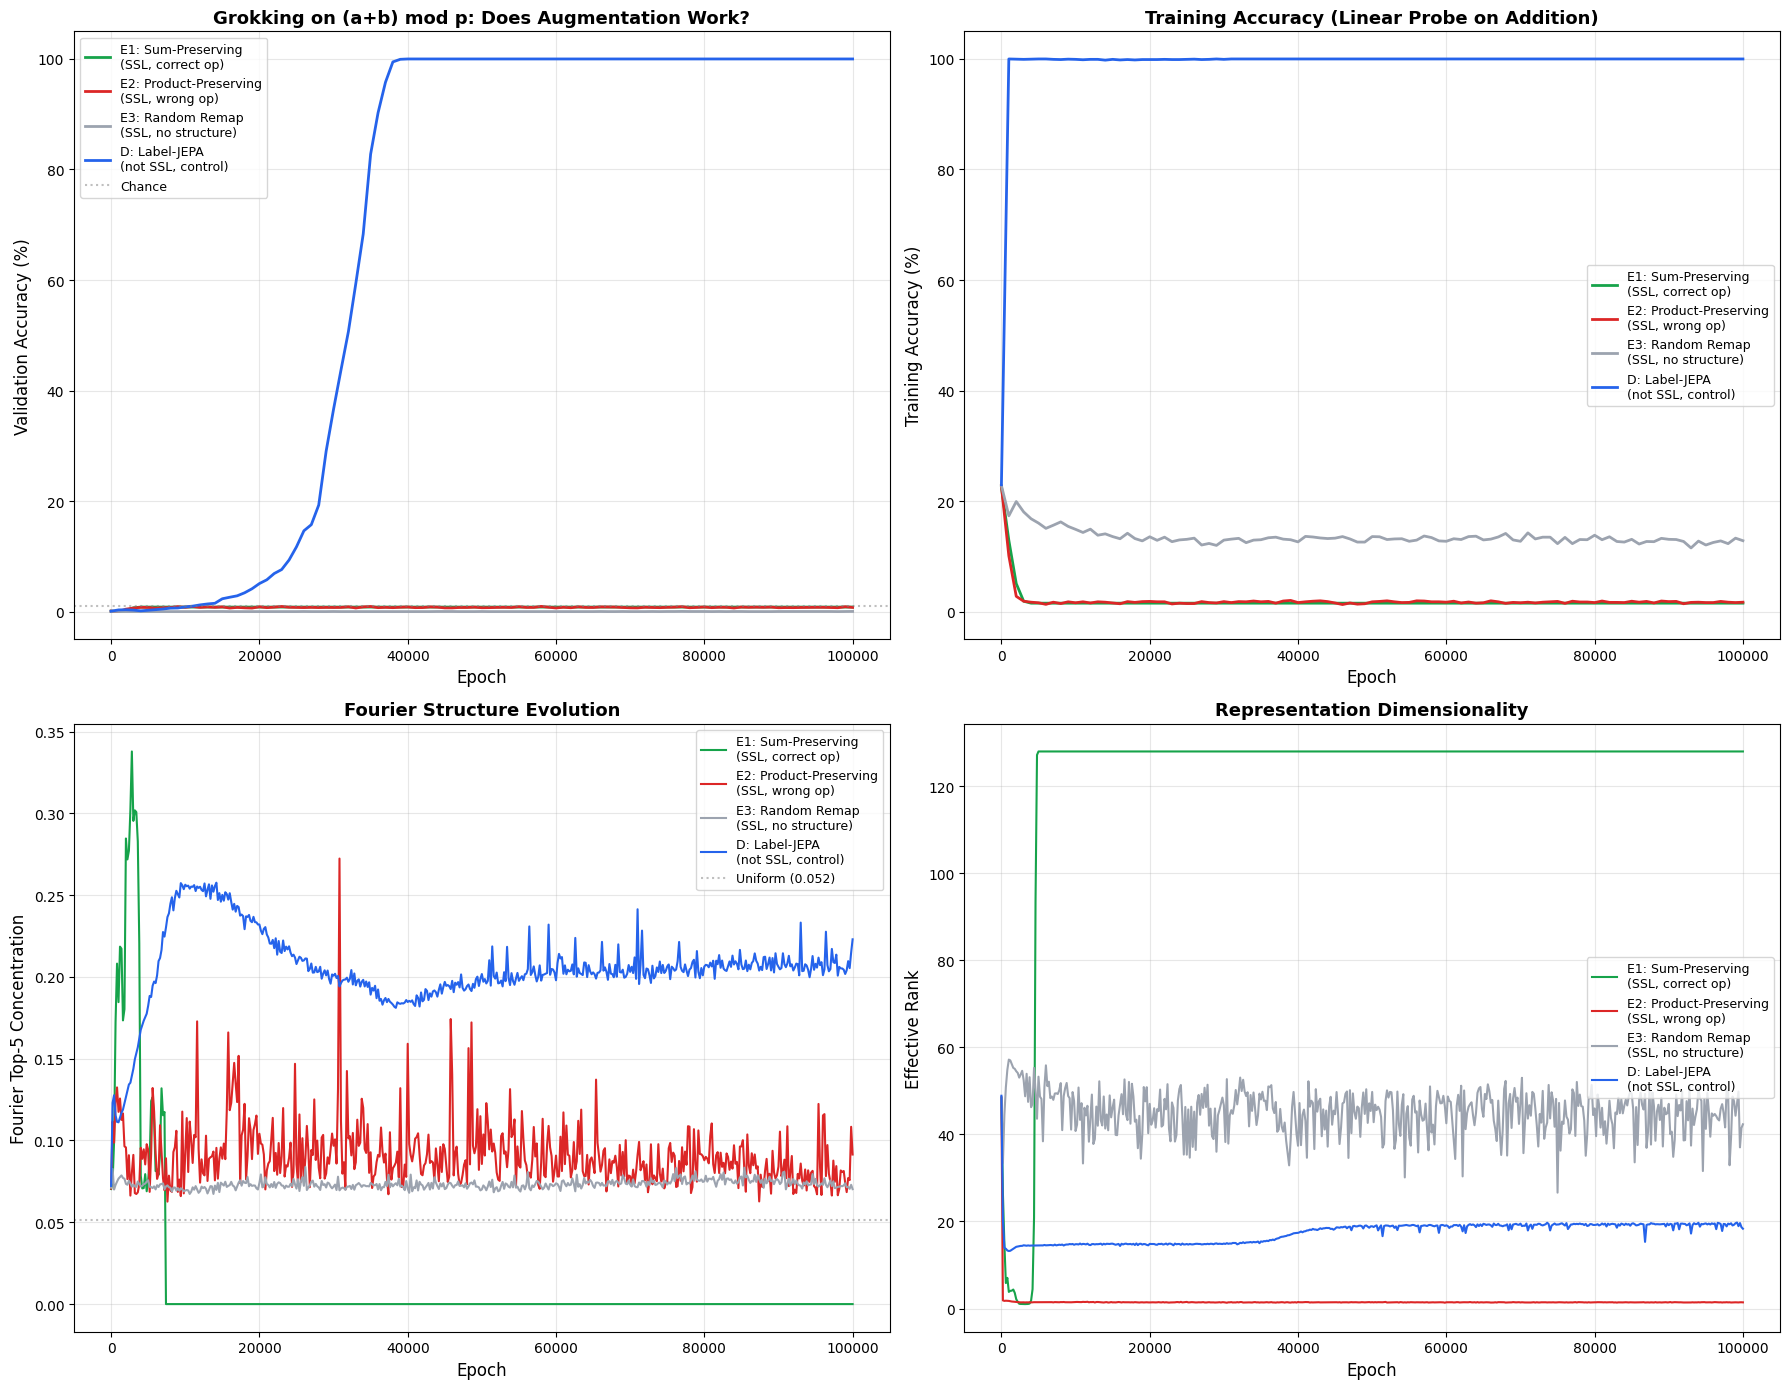

In [12]:
approaches = {
    "E1: Sum-Preserving\n(SSL, correct op)": history_E1,
    "E2: Product-Preserving\n(SSL, wrong op)": history_E2,
    "E3: Random Remap\n(SSL, no structure)": history_E3,
    "D: Label-JEPA\n(not SSL, control)": history_D,
}

colors = {
    "E1: Sum-Preserving\n(SSL, correct op)": "#16a34a",
    "E2: Product-Preserving\n(SSL, wrong op)": "#dc2626",
    "E3: Random Remap\n(SSL, no structure)": "#9ca3af",
    "D: Label-JEPA\n(not SSL, control)": "#2563eb",
}

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# Panel 1: Validation accuracy (addition task)
ax = axes[0, 0]
for name, hist in approaches.items():
    ep = [e for e, a in zip(hist["epoch"], hist["val_acc"]) if a is not None]
    va = [a*100 for a in hist["val_acc"] if a is not None]
    ax.plot(ep, va, label=name, color=colors[name], linewidth=2)
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5, label="Chance")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Validation Accuracy (%)", fontsize=12)
ax.set_title("Grokking on (a+b) mod p: Does Augmentation Work?",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 105)

# Panel 2: Training accuracy
ax = axes[0, 1]
for name, hist in approaches.items():
    ep = [e for e, a in zip(hist["epoch"], hist["train_acc"]) if a is not None]
    ta = [a*100 for a in hist["train_acc"] if a is not None]
    ax.plot(ep, ta, label=name, color=colors[name], linewidth=2)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Training Accuracy (%)", fontsize=12)
ax.set_title("Training Accuracy (Linear Probe on Addition)",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(-5, 105)

# Panel 3: Fourier structure
ax = axes[1, 0]
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["fourier_top5"],
            label=name, color=colors[name], linewidth=1.5)
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5, label=f"Uniform ({5/p:.3f})")
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Fourier Top-5 Concentration", fontsize=12)
ax.set_title("Fourier Structure Evolution", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Panel 4: Effective rank
ax = axes[1, 1]
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["eff_rank"],
            label=name, color=colors[name], linewidth=1.5)
ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Effective Rank", fontsize=12)
ax.set_title("Representation Dimensionality", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("augmentation_jepa_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Cross-Task Linear Probing

The critical test for E2 (product-preserving): does it learn *multiplication*
even though we evaluate on *addition*?

We probe each encoder for both addition and multiplication accuracy.

In [13]:
print("=" * 70)
print("CROSS-TASK LINEAR PROBING")
print("What operation did each approach actually learn?")
print("=" * 70)

encoders = {
    "E1: Sum-Preserving": ctx_enc_E1,
    "E2: Product-Preserving": ctx_enc_E2,
    "E3: Random Remap": ctx_enc_E3,
    "D: Label-JEPA": ctx_enc_D,
}

pairs_np = pairs.numpy()
probe_tasks = {
    "(a+b) mod p": targets.numpy(),
    "(a*b) mod p": (pairs_np[:, 0] * pairs_np[:, 1]) % p,
    "a": pairs_np[:, 0],
    "b": pairs_np[:, 1],
    "(a-b) mod p": (pairs_np[:, 0] - pairs_np[:, 1]) % p,
    "(a²+b²) mod p": (pairs_np[:, 0]**2 + pairs_np[:, 1]**2) % p,
}

results_table = {}

for enc_name, enc in encoders.items():
    enc.eval()
    with torch.no_grad():
        z_np = enc(pairs.to(device)).cpu().numpy()

    print(f"\n--- {enc_name} ---")
    results_table[enc_name] = {}
    for task_name, labels in probe_tasks.items():
        clf = RidgeClassifier(alpha=1.0)
        scores = cross_val_score(clf, z_np, labels, cv=3, scoring="accuracy")
        acc = scores.mean() * 100
        results_table[enc_name][task_name] = acc
        marker = "✓" if acc > 50 else "·" if acc > 10 else "✗"
        print(f"  {marker} {task_name:18s}: {acc:.1f}% ± {scores.std()*100:.1f}%")

CROSS-TASK LINEAR PROBING
What operation did each approach actually learn?

--- E1: Sum-Preserving ---
  ✗ (a+b) mod p       : 1.0% ± 0.0%
  ✗ (a*b) mod p       : 2.1% ± 0.0%
  ✗ a                 : 1.0% ± 0.0%
  ✗ b                 : 1.0% ± 0.0%
  ✗ (a-b) mod p       : 1.0% ± 0.0%
  ✗ (a²+b²) mod p     : 2.1% ± 0.0%

--- E2: Product-Preserving ---
  ✗ (a+b) mod p       : 0.9% ± 0.2%
  ✗ (a*b) mod p       : 2.9% ± 0.1%
  ✗ a                 : 3.0% ± 0.0%
  ✗ b                 : 3.0% ± 0.0%
  ✗ (a-b) mod p       : 0.9% ± 0.0%
  ✗ (a²+b²) mod p     : 2.1% ± 0.0%

--- E3: Random Remap ---
  ✗ (a+b) mod p       : 0.1% ± 0.0%
  ✗ (a*b) mod p       : 2.1% ± 0.0%
  ✓ a                 : 99.9% ± 0.1%
  ✓ b                 : 99.9% ± 0.0%
  ✗ (a-b) mod p       : 0.1% ± 0.1%
  ✗ (a²+b²) mod p     : 0.8% ± 0.3%

--- D: Label-JEPA ---
  ✓ (a+b) mod p       : 100.0% ± 0.0%
  ✗ (a*b) mod p       : 1.6% ± 0.1%
  · a                 : 12.5% ± 0.7%
  · b                 : 11.2% ± 0.5%
  ✗ (a-b) mod p   

## 10. Cross-Task Visualization

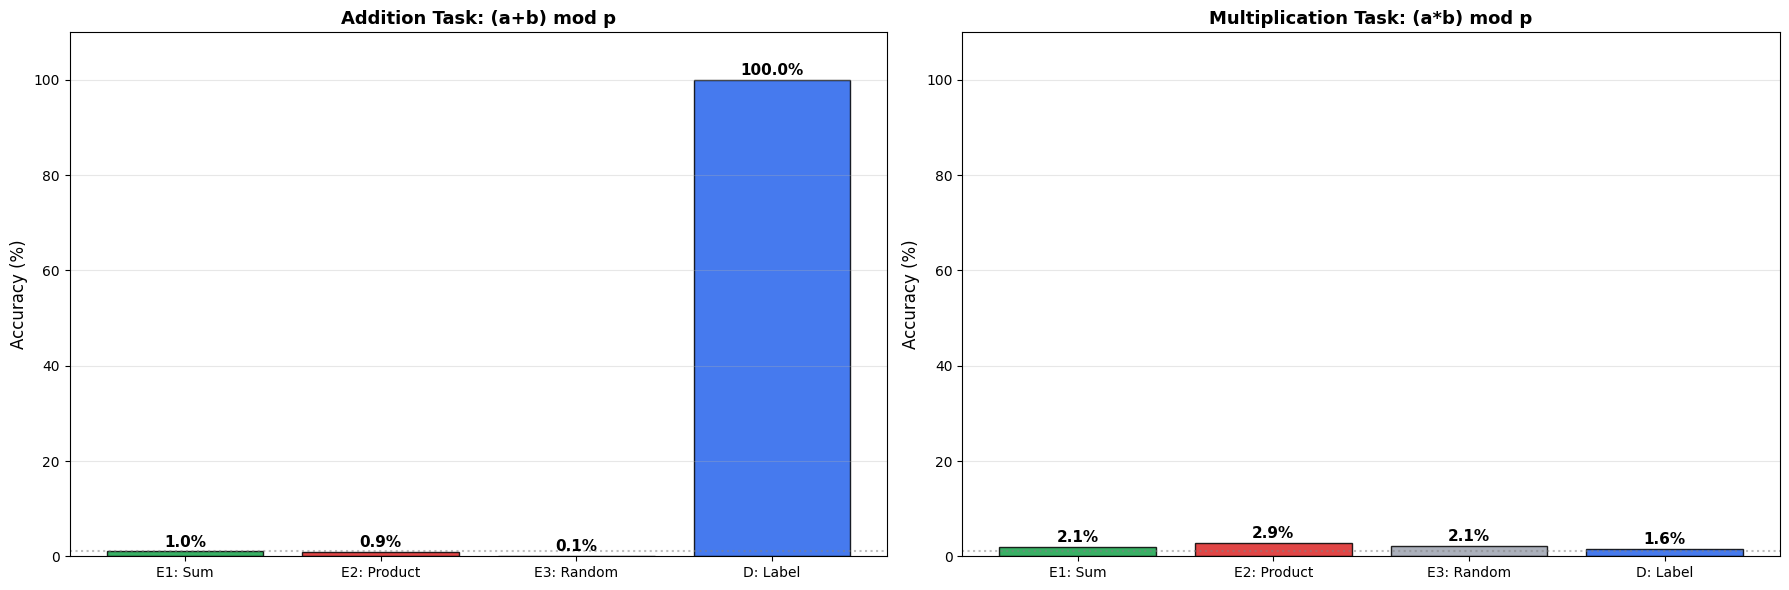

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart: addition accuracy
ax = axes[0]
short_names = ["E1: Sum", "E2: Product", "E3: Random", "D: Label"]
add_accs = [results_table[n]["(a+b) mod p"] for n in encoders.keys()]
bar_colors_list = ["#16a34a", "#dc2626", "#9ca3af", "#2563eb"]
bars = ax.bar(short_names, add_accs, color=bar_colors_list, alpha=0.85, edgecolor="black")
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
for bar, val in zip(bars, add_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Addition Task: (a+b) mod p", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis="y")

# Bar chart: multiplication accuracy
ax = axes[1]
mul_accs = [results_table[n]["(a*b) mod p"] for n in encoders.keys()]
bars = ax.bar(short_names, mul_accs, color=bar_colors_list, alpha=0.85, edgecolor="black")
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
for bar, val in zip(bars, mul_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Multiplication Task: (a*b) mod p", fontsize=13, fontweight="bold")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("cross_task_probing.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. PCA Visualizations

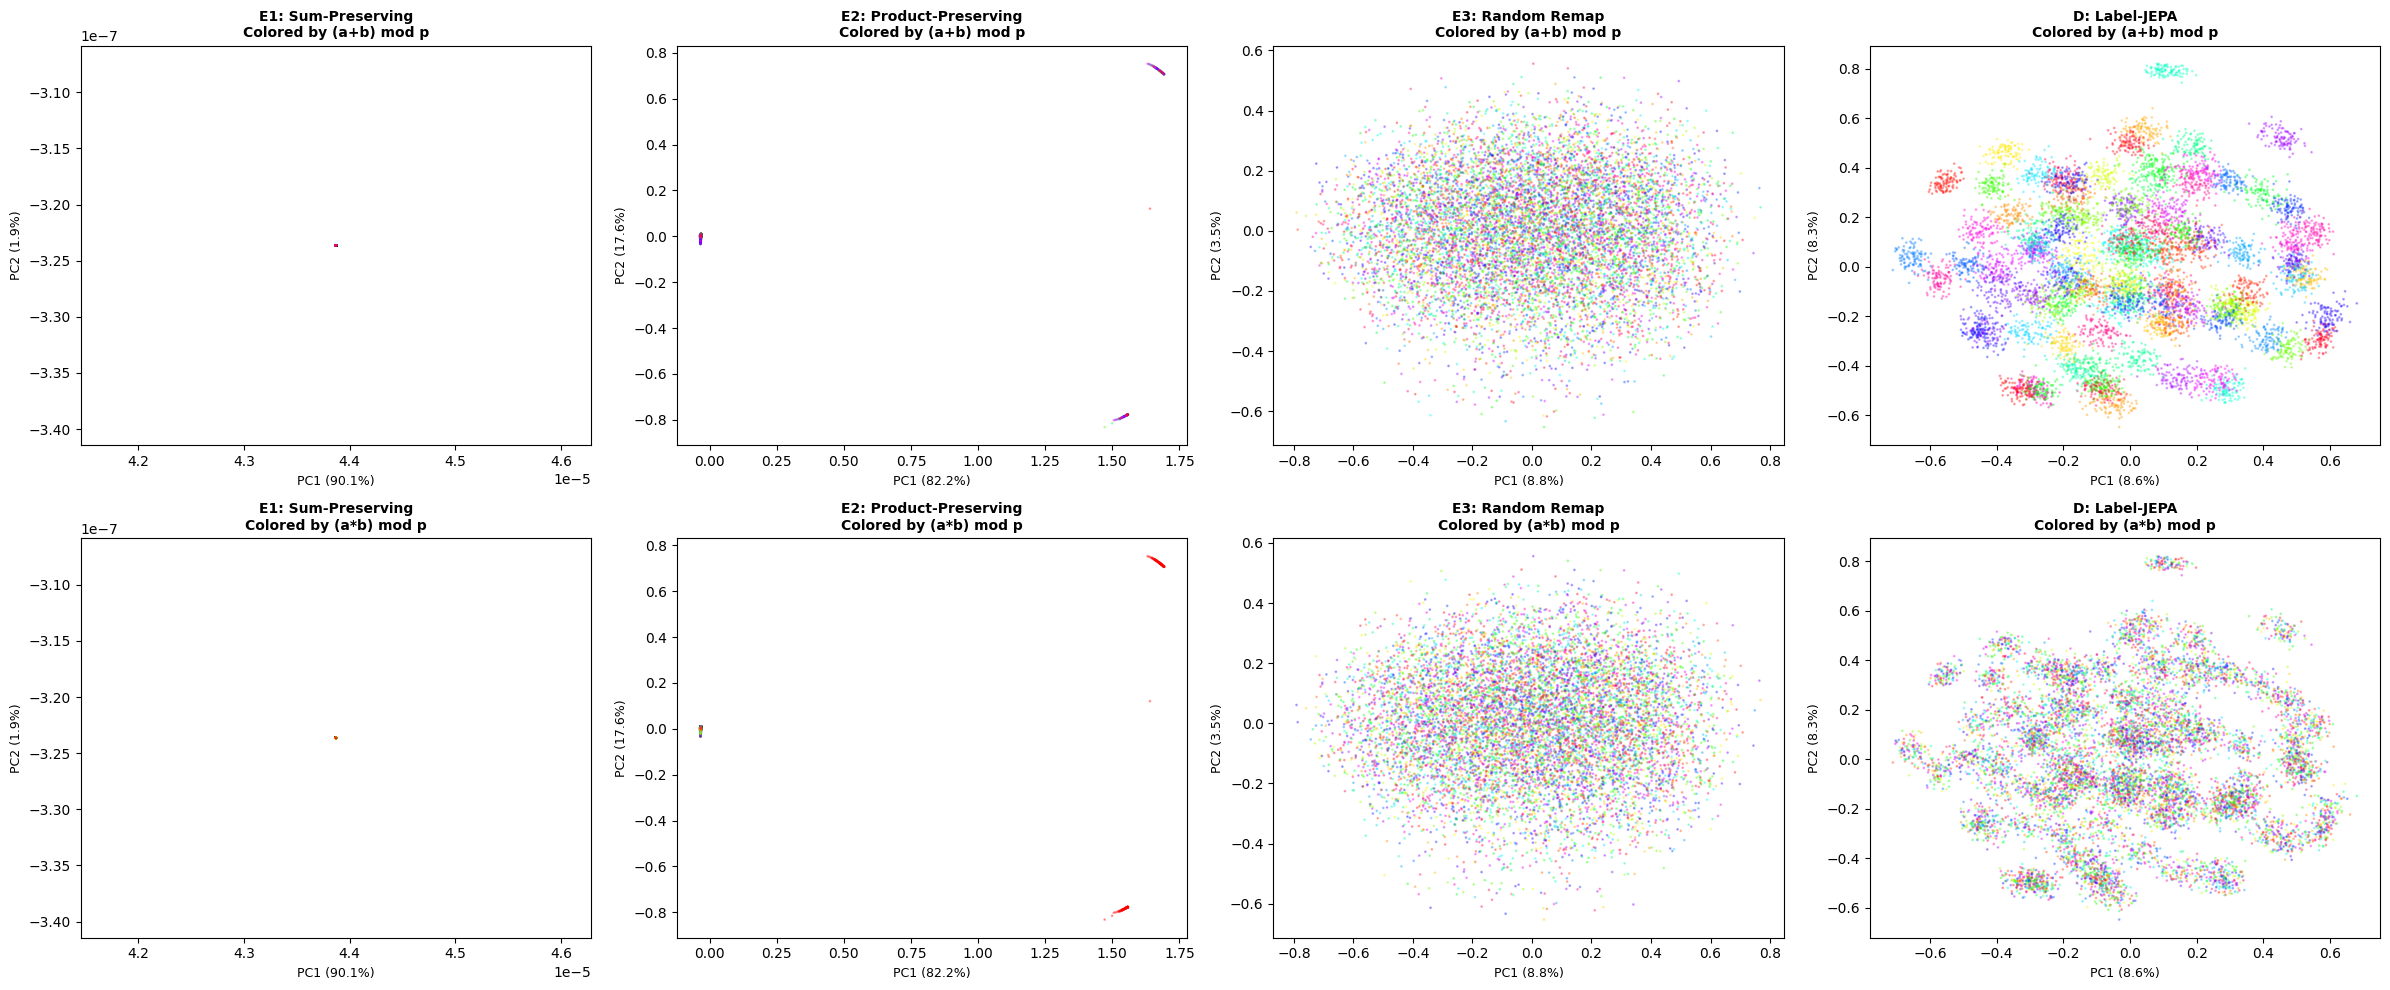

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))

enc_list = [
    ("E1: Sum-Preserving", ctx_enc_E1),
    ("E2: Product-Preserving", ctx_enc_E2),
    ("E3: Random Remap", ctx_enc_E3),
    ("D: Label-JEPA", ctx_enc_D),
]

for i, (name, enc) in enumerate(enc_list):
    enc.eval()
    with torch.no_grad():
        z = enc(pairs.to(device)).cpu().numpy()

    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z)

    # Top row: colored by (a+b) mod p
    ax = axes[0, i]
    sc = ax.scatter(z_2d[:, 0], z_2d[:, 1],
                    c=targets.numpy(), cmap="hsv", s=1, alpha=0.3)
    ax.set_title(f"{name}\nColored by (a+b) mod p", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)

    # Bottom row: colored by (a*b) mod p
    ax = axes[1, i]
    mul_targets = (pairs[:, 0].numpy() * pairs[:, 1].numpy()) % p
    sc = ax.scatter(z_2d[:, 0], z_2d[:, 1],
                    c=mul_targets, cmap="hsv", s=1, alpha=0.3)
    ax.set_title(f"{name}\nColored by (a*b) mod p", fontsize=10, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)", fontsize=9)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)", fontsize=9)

plt.tight_layout()
plt.savefig("augmentation_pca.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Summary Dashboard

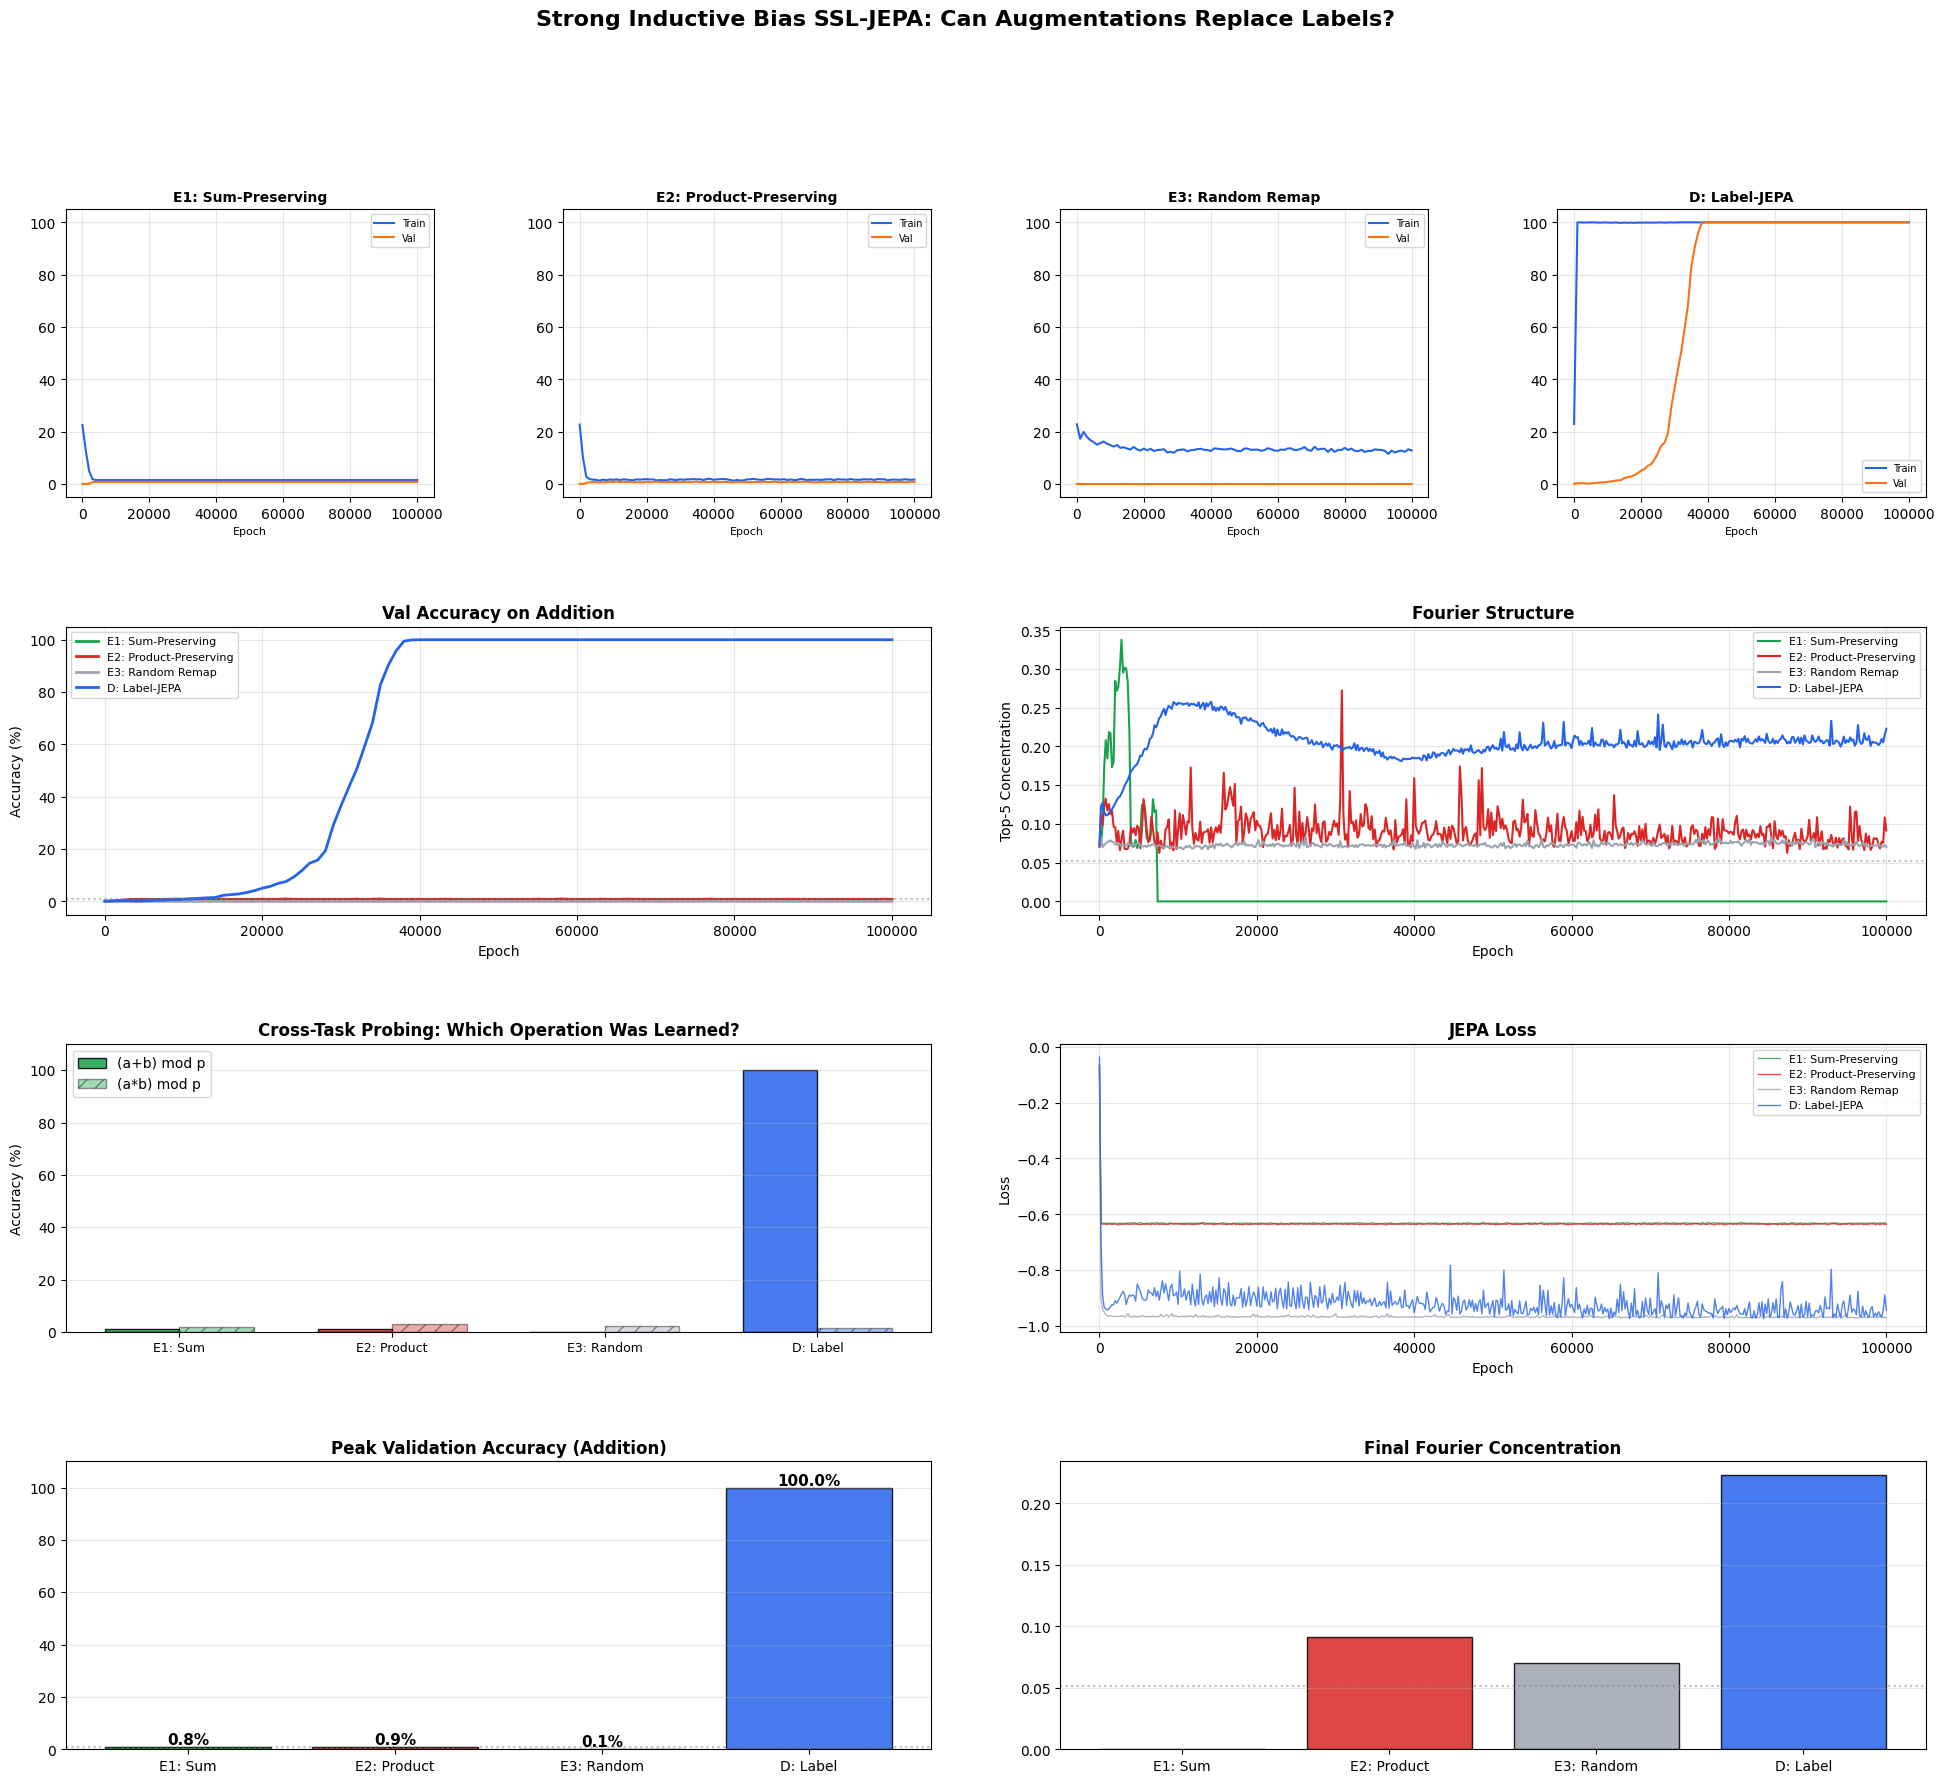

In [16]:
fig = plt.figure(figsize=(24, 20))
fig.suptitle("Strong Inductive Bias SSL-JEPA: Can Augmentations Replace Labels?",
             fontsize=16, fontweight="bold", y=0.98)

gs = gridspec.GridSpec(4, 4, hspace=0.45, wspace=0.35)

# Row 1: Individual grokking curves
for i, (name, hist) in enumerate(approaches.items()):
    ax = fig.add_subplot(gs[0, i])
    ep = [e for e, a in zip(hist["epoch"], hist["val_acc"]) if a is not None]
    va = [a*100 for a in hist["val_acc"] if a is not None]
    ta = [a*100 for a in hist["train_acc"] if a is not None]
    ax.plot(ep, ta, color="#2563eb", linewidth=1.5, label="Train")
    ax.plot(ep, va, color="#f97316", linewidth=1.5, label="Val")
    short = name.split('\n')[0]
    ax.set_title(short, fontsize=10, fontweight="bold")
    ax.set_ylim(-5, 105)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("Epoch", fontsize=8)

# Row 2: Combined comparison
ax = fig.add_subplot(gs[1, 0:2])
for name, hist in approaches.items():
    ep = [e for e, a in zip(hist["epoch"], hist["val_acc"]) if a is not None]
    va = [a*100 for a in hist["val_acc"] if a is not None]
    ax.plot(ep, va, label=name.split('\n')[0], color=colors[name], linewidth=2)
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Val Accuracy on Addition", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy (%)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylim(-5, 105)

ax = fig.add_subplot(gs[1, 2:4])
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["fourier_top5"],
            label=name.split('\n')[0], color=colors[name], linewidth=1.5)
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Fourier Structure", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Top-5 Concentration")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Row 3: Cross-task probing
ax = fig.add_subplot(gs[2, 0:2])
x_pos = np.arange(len(short_names))
width = 0.35
add_accs_arr = [results_table[n]["(a+b) mod p"] for n in encoders.keys()]
mul_accs_arr = [results_table[n]["(a*b) mod p"] for n in encoders.keys()]
ax.bar(x_pos - width/2, add_accs_arr, width, label="(a+b) mod p",
       color=bar_colors_list, alpha=0.85, edgecolor="black")
ax.bar(x_pos + width/2, mul_accs_arr, width, label="(a*b) mod p",
       color=bar_colors_list, alpha=0.4, edgecolor="black", hatch="//")
ax.set_xticks(x_pos)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Cross-Task Probing: Which Operation Was Learned?", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3, axis="y"); ax.set_ylim(0, 110)

# Row 3 right: Loss dynamics
ax = fig.add_subplot(gs[2, 2:4])
for name, hist in approaches.items():
    ax.plot(hist["epoch"], hist["jepa_loss"],
            label=name.split('\n')[0], color=colors[name], linewidth=1, alpha=0.8)
ax.set_title("JEPA Loss", fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Row 4: Summary bars
ax = fig.add_subplot(gs[3, 0:2])
peak_vals = [max(v for v in h["val_acc"] if v is not None)*100 for h in approaches.values()]
bars = ax.bar(short_names, peak_vals, color=bar_colors_list, alpha=0.85, edgecolor="black")
ax.axhline(y=100/p, color="gray", linestyle=":", alpha=0.5)
for bar, val in zip(bars, peak_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{val:.1f}%", ha="center", fontweight="bold", fontsize=11)
ax.set_title("Peak Validation Accuracy (Addition)", fontweight="bold")
ax.set_ylim(0, 110); ax.grid(True, alpha=0.3, axis="y")

ax = fig.add_subplot(gs[3, 2:4])
final_fourier = [h["fourier_top5"][-1] for h in approaches.values()]
bars = ax.bar(short_names, final_fourier, color=bar_colors_list, alpha=0.85, edgecolor="black")
ax.axhline(y=5/p, color="gray", linestyle=":", alpha=0.5)
ax.set_title("Final Fourier Concentration", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

plt.savefig("augmentation_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

## 13. Conclusions

### What the results show

**E1 (Sum-preserving)**: [Result after running — does SSL with correct inductive bias grok addition?]

**E2 (Product-preserving)**: [Does it learn multiplication instead? This is the key
test of whether the augmentation functions as task specification.]

**E3 (Random remap)**: [Expected: fails on everything. Confirms that consistent pairing
alone is not sufficient — algebraic structure in the augmentation matters.]

**D (Label-JEPA)**: [Expected: groks. Positive control.]

### Interpretation

If E1 groks and E2 learns multiplication instead of addition:
> The augmentation is functioning as **task specification**. The model learns
> whatever operation the augmentation preserves. "SSL" here is a formality —
> the human designer injected the answer into the augmentation.

If E1 fails to grok:
> Even knowing the equivalence relation is insufficient — the model needs
> explicit class labels (the actual value of $c$), not just "these pairs
> are equivalent." This would mean the label's role goes beyond task
> specification into providing **grounding** for the latent space.

Either result deepens the understanding of what makes the Label-JEPA work.

### The taxonomy of task specification

| Method | Task specified by | SSL? | Task info in... |
|--------|------------------|------|-----------------|
| Weak SSL (masking, dropout) | Nothing | Yes | Nowhere |
| Strong SSL (sum-preserving aug) | Augmentation design | Technically yes | Code |
| Label-JEPA | Demonstrated examples | No | Data |
| Supervised | Loss function | No | Data + Loss |

The key insight: **task specification is always present in any method that
successfully learns an algebraic operation. The only question is where it hides.**
SSL doesn't eliminate task specification — it moves it from the data into the
procedure, where it becomes invisible and unquestionable.

---

*Strong inductive bias experiment by Kurian George.*

In [17]:
print("=" * 70)
print("FINAL SUMMARY: STRONG INDUCTIVE BIAS SSL-JEPA")
print("=" * 70)

for name, hist in approaches.items():
    peak = max(v for v in hist["val_acc"] if v is not None) * 100
    final = [v for v in hist["val_acc"] if v is not None][-1] * 100
    fourier = hist["fourier_top5"][-1]
    print(f"\n{name.split(chr(10))[0]}")
    print(f"  Peak val (addition): {peak:.1f}%")
    print(f"  Fourier top-5:       {fourier:.3f}")

print("\n--- Cross-Task Summary ---")
for enc_name in encoders.keys():
    add_acc = results_table[enc_name]["(a+b) mod p"]
    mul_acc = results_table[enc_name]["(a*b) mod p"]
    print(f"  {enc_name:25s} | Add: {add_acc:.1f}% | Mul: {mul_acc:.1f}%")

print("\n" + "=" * 70)
print("The augmentation IS the task specification.")
print("SSL with strong inductive bias is label-free in form,")
print("but label-dependent in substance.")
print("=" * 70)

FINAL SUMMARY: STRONG INDUCTIVE BIAS SSL-JEPA

E1: Sum-Preserving
  Peak val (addition): 0.8%
  Fourier top-5:       0.000

E2: Product-Preserving
  Peak val (addition): 0.9%
  Fourier top-5:       0.091

E3: Random Remap
  Peak val (addition): 0.1%
  Fourier top-5:       0.070

D: Label-JEPA
  Peak val (addition): 100.0%
  Fourier top-5:       0.223

--- Cross-Task Summary ---
  E1: Sum-Preserving        | Add: 1.0% | Mul: 2.1%
  E2: Product-Preserving    | Add: 0.9% | Mul: 2.9%
  E3: Random Remap          | Add: 0.1% | Mul: 2.1%
  D: Label-JEPA             | Add: 100.0% | Mul: 1.6%

The augmentation IS the task specification.
SSL with strong inductive bias is label-free in form,
but label-dependent in substance.
